# Bilateral decoding of position from z-scored spike rates using a gaussian bayesian decoder.

**Sidney Rafilson | Buzsaki Lab**

Included is a hacked and very ilegitimate iterative fitting for latent variable estimation

In [2]:
import numpy as np
import pandas as pd

from scipy.stats import zscore, wasserstein_distance
from scipy.interpolate import interp1d
from scipy.io import loadmat
from scipy.special import logsumexp
from scipy.io import loadmat

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import plotly.graph_objects as go
from ipywidgets import interact, FloatSlider

from core import *

sns.set_context('notebook', font_scale=1.5)

## Pipeline configuration settings

In [148]:
# ----------------------------- Config ---------------------------------

# Data paths and session info
DATA_DIR = r"\\research-cifs.nyumc.org\research\buzsakilab\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106"
FIG_DIR = r"\\research-cifs.nyumc.org\research\buzsakilab\Homes\voerom01\Bilat_HPC\Bilat_R02\Bilat_R02_20251106\analysisFigures"
SESSION_NAME = "pre_sleep_g0"
BASE_NAME = "Bilat_R02_20251106"
PROBES = [0, 1, 2, 3]


# Spike rate computation parameters
WINDOW_SIZE = 0.01         # s
STEP_SIZE   = 0.01        # s
SIGMA       = 5          # smoothing sigma (0 -> no smoothing)
USE_UNITS   = "good"       # {'all', 'good', 'mua'}
NORMALIZE   = True         # z-score each unit's rates

# Filtering thresholds
MIN_TOTAL_SPIKES   = 100
MIN_MEAN_RATE_HZ   = 0.01
MIN_PRESENCE_RATIO = 0.75
N_TIME_BINS        = 100    # coarse bins for presence ratio


# defining the region dictionary. Keys are probe numbers, values are dictionaries which are further mapping shanks to regions
#region_dict = {0: {0: 'CA1', 1: 'RSP', 2: 'CA3', 3: 'CA1', 4: 'RSP', 5: 'CA3', 6: 'CA1', 7: 'RSP'}, 1: {0: 'CA3', 1: 'CA1', 2: 'CA2', 3: 'A1', 4: 'S1'}, 2: {0: 'CA3', 1: 'Th', 2: 'V1', 3: 'Th', 4: 'CA1', 5: 'V1', 6: 'CA1', 7: 'V1'}} UDS
region_dict = {
    0: {0: 'CA1', 1: 'Th', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    1: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'},
    2: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6:'CA1'}, 
    3: {0: 'CA1', 1: 'CA1', 2: 'CA1', 3: 'CA1', 4: 'CA1', 5: 'CA1', 6: 'CA1', 7: 'CA1'}
}


# defining the hemisphere dictionary. Keys are probe numbers, values are 'L' or 'R' for left/right hemisphere
hemisphere_dict = {0: 'L', 1: 'L', 2: 'R', 3: 'R'}

# Create figure directory if it doesn't exist
os.makedirs(FIG_DIR, exist_ok=True)

In [ ]:
# ------------------------ Optionally save & load region dictionary ------------------------
save_region_dict = True
if save_region_dict:
    dict_file = open(os.path.join(DATA_DIR, 'region_dict.pkl'), 'wb')
    dict_file.write(str(region_dict).encode())
    dict_file.close()

load_region_dict = True
if load_region_dict:
    dict_file = open(os.path.join(DATA_DIR, 'region_dict.pkl'), 'rb')
    region_dict = eval(dict_file.read().decode())
    dict_file.close()


## Loading the spike rate matrices

In [149]:
# ------------------------ Load spike rate matrices ------------------------
spike_rate_matrices = {}
cell_types = {}
regions = {}
for probe in PROBES:
    # Get the raw spike counts and the zscored and smoothed spike rates
    ks_dir = os.path.join(DATA_DIR, f'Kilosort_imec{probe}_ks4')
    raw_rates, time_bins, units = compute_spike_rates(str(ks_dir), WINDOW_SIZE, STEP_SIZE, USE_UNITS, 0.0, False, adj = '_sec_adj')
    spike_rate_matrix, _, _ = compute_spike_rates(str(ks_dir), WINDOW_SIZE, STEP_SIZE, USE_UNITS, SIGMA, NORMALIZE, adj = '_sec_adj')
    est_counts_per_bin = raw_rates * WINDOW_SIZE


    # computing the filtering metrics
    total_spikes   = est_counts_per_bin.sum(axis=1)         
    mean_rate_hz   = raw_rates.mean(axis=1)
    presence_ratio = get_presence_ratio(est_counts_per_bin, time_bins, N_TIME_BINS)

    mask = (
        (total_spikes >= MIN_TOTAL_SPIKES) &
        (mean_rate_hz >= MIN_MEAN_RATE_HZ) &
        (presence_ratio >= MIN_PRESENCE_RATIO)
    )


    # Apply mask to spike rate matrix and unit list
    spike_rate_matrix = spike_rate_matrix[mask, :]
    units = [u for u, keep in zip(units, mask) if keep]
    print(f"Probe {probe}: Keeping {mask.sum()} / {mask.sum() + (~mask).sum()} units after filtering.\nspike_rate_matrix shape: {spike_rate_matrix.shape}\n")

    # remove units based on presence ratio
    spike_rate_matrices[probe] = (spike_rate_matrix, time_bins, units)


    # Load the cell metrics
    cell_metrics_file = os.path.join(DATA_DIR, f'{BASE_NAME}_imec{probe}.cell_metrics.cellinfo.mat')
    cell_type = loadmat(cell_metrics_file)['cell_metrics']['putativeCellType'][0,0].flatten()
    shank_ids = loadmat(cell_metrics_file)['cell_metrics']['shankID'][0,0].flatten()


    # keeping only the string labels
    cell_type = np.array([ct[0] if isinstance(ct, np.ndarray) else ct for ct in cell_type])

    # removing mask applied units from cell type
    cell_types[probe] = cell_type[mask]
    regions[probe] = np.array([region_dict[probe][shank_id-1] for shank_id in shank_ids[mask]])  # shank IDs are 1-based

Probe 0: Keeping 76 / 80 units after filtering.
spike_rate_matrix shape: (76, 1052094)

Probe 1: Keeping 45 / 49 units after filtering.
spike_rate_matrix shape: (45, 1052094)

Probe 2: Keeping 276 / 299 units after filtering.
spike_rate_matrix shape: (276, 1052094)

Probe 3: Keeping 292 / 305 units after filtering.
spike_rate_matrix shape: (292, 1052094)



## Getting position tracking

In [150]:
# Loading the manually extracted TTL times
manual_ttl_file = os.path.join(DATA_DIR, 'manual_ttl_extraction.csv')
manual_ttls_df = pd.read_csv(manual_ttl_file)
ttls = manual_ttls_df['ttl_times_sec'].values

Number of frames: 308232
first row of tracking data: [ 0.00000e+00  0.00000e+00  6.81780e-02 -1.61595e-01 -9.67768e-01
 -1.80732e-01 -1.07200e-03  2.23371e-01  5.83550e-02  4.13000e-04]
Trimming TTLs from 308285 to 308232
Tracking start time: 3926.353 s, end time: 6494.814 s, duration: 2568.461 s


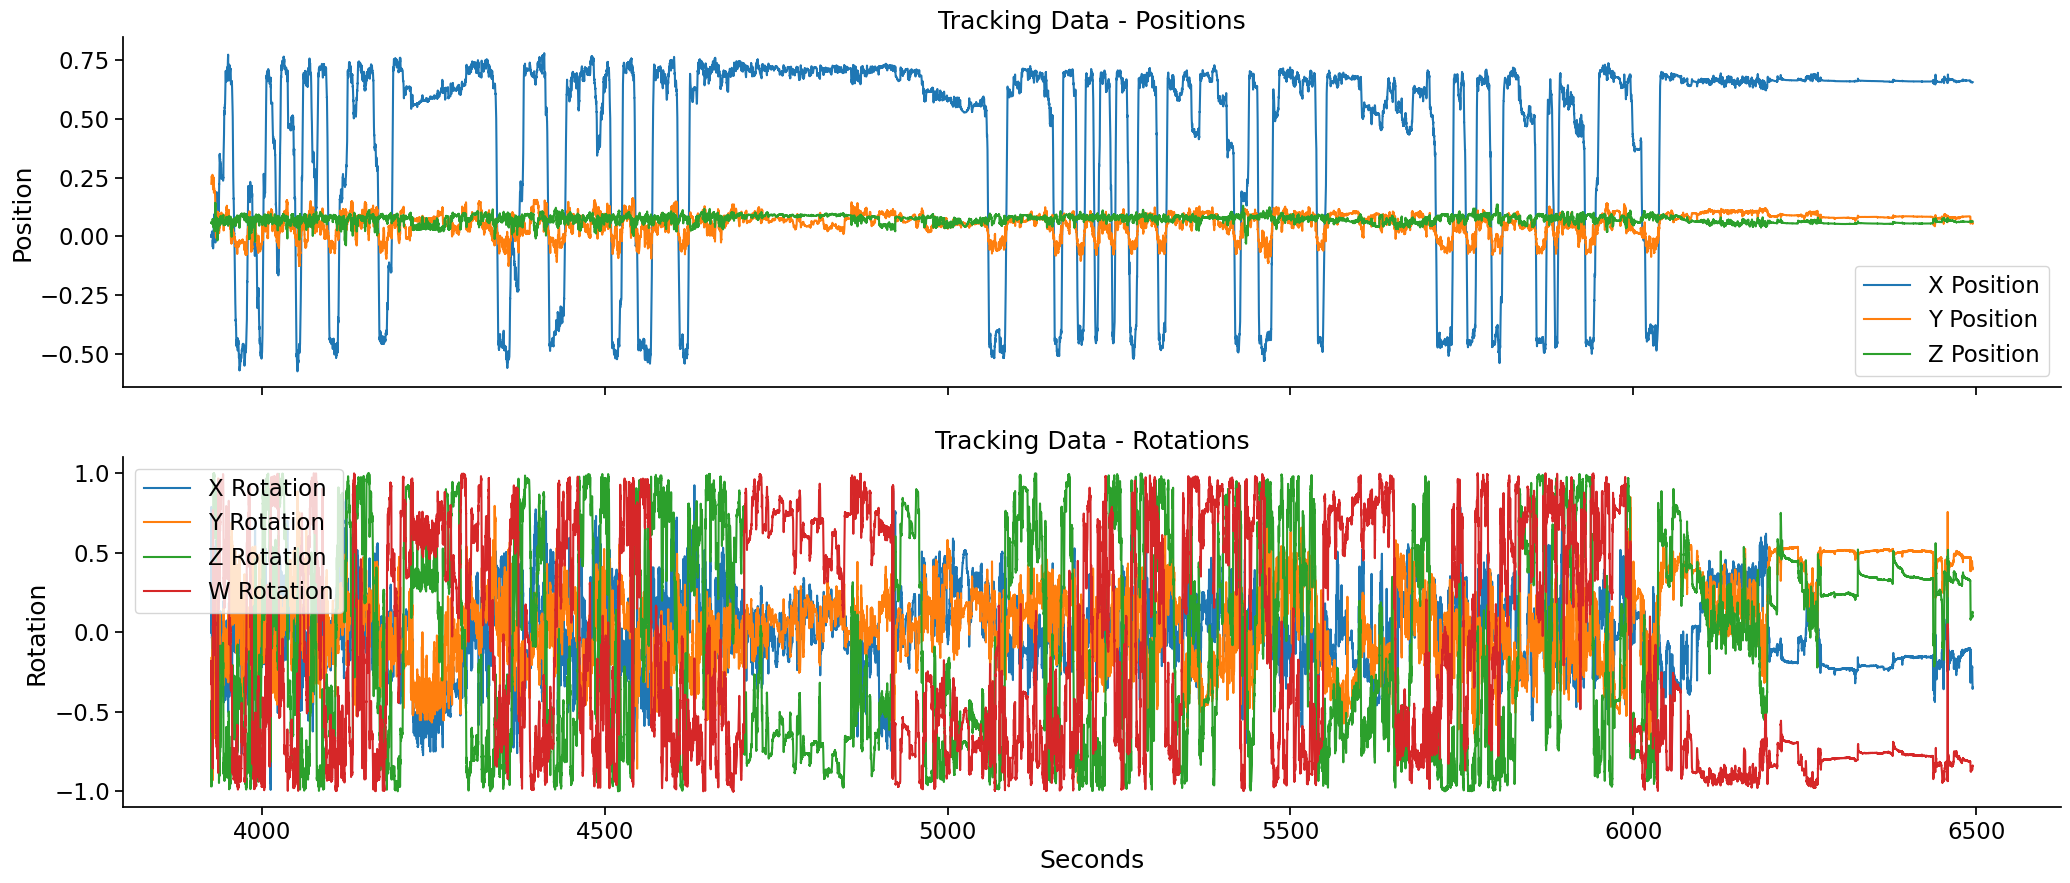

In [151]:
# Loadding in the tracking data
tracking_file = os.path.join(DATA_DIR, "Bilat_R02_20251106_linear_maze_000.csv")
tracking_data = np.genfromtxt(tracking_file, delimiter=",", skip_header=7)
frames = tracking_data[:,0]
print(f'Number of frames: {len(frames)}')
print(f'first row of tracking data: {tracking_data[0,:]}')


# Sometimes there are a few more frames after the last TTL or more TTLs than frames. We will trim the data to the shortest length.
if len(frames) < len(ttls):
    print(f'Trimming TTLs from {len(ttls)} to {len(frames)}')
    ttls = ttls[:len(frames)]
    tracking_data = tracking_data[:len(frames),:]
elif len(frames) > len(ttls):
    print(f'Trimming frames from {len(frames)} to {len(ttls)}')
    frames = frames[:len(ttls)]
    tracking_data = tracking_data[:len(ttls),:]

# printing the start and end times
print(f'Tracking start time: {ttls[0]:.3f} s, end time: {ttls[-1]:.3f} s, duration: {ttls[-1]-ttls[0]:.3f} s')


# fill missing values or nan with linear interpolation
for i in range(tracking_data.shape[1]):
    col = tracking_data[:,i]
    nans = np.isnan(col)
    if np.any(nans):
        not_nans = ~nans
        interp_func_col = interp1d(frames[not_nans], col[not_nans], bounds_error=False, fill_value="extrapolate")
        col[nans] = interp_func_col(frames[nans])
        tracking_data[:,i] = col

# extract x, y, z positions and rotations
x_rotations = tracking_data[:,2]
y_rotations = tracking_data[:,3]
z_rotations = tracking_data[:,4]
w_rotations = tracking_data[:,5]
x_positions = tracking_data[:,6]
y_positions = tracking_data[:,7]
z_positions = tracking_data[:,8]

# Plotting the tracking data
fig, axs = plt.subplots(2, 1, figsize=(25,10), sharex=True)

sns.lineplot(ax=axs[0], x=ttls, y=x_positions, label='X Position')
sns.lineplot(ax=axs[0], x=ttls, y=y_positions, label='Y Position')
sns.lineplot(ax=axs[0], x=ttls, y=z_positions, label='Z Position')
axs[0].set_ylabel('Position')
axs[0].set_title('Tracking Data - Positions')

sns.lineplot(ax=axs[1], x=ttls, y=x_rotations, label='X Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=y_rotations, label='Y Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=z_rotations, label='Z Rotation')
sns.lineplot(ax=axs[1], x=ttls, y=w_rotations, label='W Rotation')
axs[1].set_xlabel('Seconds')
axs[1].set_ylabel('Rotation')
axs[1].set_title('Tracking Data - Rotations')
sns.despine()
#plt.savefig(os.path.join(FIG_DIR, "tracking_data.png"), dpi=300)
plt.show()


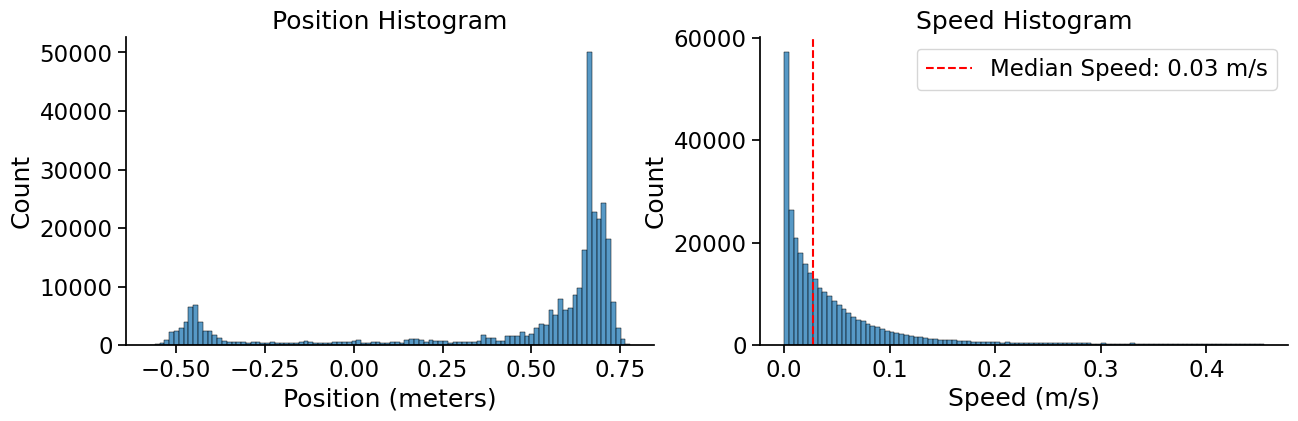

In [152]:
# choose which position to use
pos_raw = x_positions  # original position samples aligned to `frames` (units: cm)
assert frames.shape[0] == pos_raw.shape[0]

# compute the velocity
velocity = np.gradient(pos_raw) / np.gradient(ttls)  # velocity in m/s

# getting the running direction
running_direction = np.sign(velocity)

# getting the speed
speed = np.abs(velocity)  # speed in m/s

# Plotting some position statistics
fig, axs = plt.subplots(1, 2, figsize=(15,4))
sns.histplot(ax=axs[0], x=pos_raw, bins=100)
axs[0].set_xlabel('Position (meters)')
axs[0].set_ylabel('Count')
axs[0].set_title('Position Histogram')

sns.histplot(ax=axs[1], x=speed[speed < np.percentile(speed, 99)], bins=100)
axs[1].set_xlabel('Speed (m/s)')
axs[1].set_ylabel('Count')
axs[1].set_title('Speed Histogram')
axs[1].axvline(x = np.median(speed), color='red', linestyle='--', label=f'Median Speed: {np.median(speed):.2f} m/s')
axs[1].legend()
sns.despine()
plt.savefig(os.path.join(FIG_DIR, "position_statistics.png"), dpi=300)
plt.show()


In [ ]:
# ------------------------------------- Baysian decoding configuration --------------------------------------
use_regions = ['CA1']
use_unit_types = ['Pyramidal Cell']
n_spatial_bins = 25
pos_min, pos_max = -0.5, 0.7
speed_threshold = 0.03  # speed threshold for training (m/s)



# compute the spatial bin edges
bin_edges = np.linspace(pos_min, pos_max, n_spatial_bins + 1)

# Creating interpolation function for position
pos_interp_func = interp1d(ttls, pos_raw, kind = 'linear', bounds_error=False, fill_value=np.nan)

# getting the spike rates for the selected hemispheres
selected_spike_rates_train_L = []
selected_spike_rates_train_R = []
selected_spike_rates_test_L = []
selected_spike_rates_test_R = []

# getting reference time from probe with shortest timebins
tb_ref = None
for probe in PROBES:
    _, tb_probe, _ = spike_rate_matrices[probe]
    if tb_ref is None:
        tb_ref = tb_probe
    elif len(tb_probe) < len(tb_ref):
        tb_ref = tb_probe

# Build canonical masks on the *reference* tb_ref
pos_ref = pos_interp_func(tb_ref)
valid_ttl  = (tb_ref >= np.min(ttls)) & (tb_ref <= np.max(ttls))
print(f'number of valid TTL timebins: {valid_ttl.sum()} / {len(tb_ref)}')
finite_pos = np.isfinite(pos_ref)
print(f'number of finite position timebins: {finite_pos.sum()} / {len(tb_ref)}')

# apply speed thresholding
if speed_threshold > 0:
    vel_ref   = np.gradient(pos_ref, tb_ref)
    speed_ref = gaussian_filter1d(np.abs(vel_ref), sigma=1)
    move_mask = speed_ref > speed_threshold
else:
    move_mask = np.ones_like(tb_ref, dtype=bool)
print(f'number of movement timebins: {move_mask.sum()} / {len(tb_ref)}')

# final canonical masking
canon_mask_train = valid_ttl & finite_pos & move_mask
time_bins_train  = tb_ref[canon_mask_train]
speed_train = speed_ref[canon_mask_train]
pos_canon_train = pos_ref[canon_mask_train]

canon_mask_test = finite_pos & valid_ttl
time_bins_test  = tb_ref[canon_mask_test]
speed_test = speed_ref[canon_mask_test]
pos_canon_test = pos_ref[canon_mask_test]

# digitizing the position into spatial bins
pos_idx_train = np.digitize(pos_canon_train, bin_edges, right=True)
pos_idx_train = np.clip(pos_idx_train, 0, n_spatial_bins - 1)
pos_idx_test = np.digitize(pos_canon_test, bin_edges, right=True)
pos_idx_test = np.clip(pos_idx_test, 0, n_spatial_bins - 1)


# looping over probes to collect spike rates
for probe in PROBES:

    spike_rate_matrix, probe_times, units = spike_rate_matrices[probe]  # (n_units, n_timebins)
    hemisphere = hemisphere_dict[probe]


    # cropping the probe times to match the reference timebins
    print(f'Probe {probe} timebins length {len(probe_times)}: reference timebins length {len(tb_ref)}')
    start_time, end_time = np.min(tb_ref), np.max(tb_ref)
    valid_time_probe = (probe_times >= start_time) & (probe_times <= end_time)

    # check if all time values are now equal
    probe_times = probe_times[valid_time_probe]
    spike_rate_matrix = spike_rate_matrix[:, valid_time_probe]
        
    if np.allclose(probe_times, tb_ref, rtol=0, atol=1e-9):
        print(f'Probe {probe} timebins successfully matched to reference timebins after cropping.')
        print(f'sum of differences: {np.sum(probe_times - tb_ref)}\n')
    else:
        raise ValueError(f'Probe {probe} timebins do not match reference timebins after cropping. Lengths: {len(probe_times)} vs {len(tb_ref)}')


    # filtering out timebins outside the TTL range and speed threshold
    spike_rate_matrix_train = spike_rate_matrix[:, canon_mask_train]
    spike_rate_matrix_test = spike_rate_matrix[:, canon_mask_test]

    # getting cell types and regions for the current probe
    ct_probe = np.asarray(cell_types[probe])                    
    rgn_arr = regions[probe]                                   

    # select units from the selected regions
    unit_sel = np.where(
        (np.isin(ct_probe, use_unit_types)) &
        (np.isin(rgn_arr, use_regions))
    )[0]
    if unit_sel.size == 0:
        continue

    if hemisphere == 'L':
        selected_spike_rates_train_L.append(spike_rate_matrix_train[unit_sel, :])
        selected_spike_rates_test_L.append(spike_rate_matrix_test[unit_sel, :])
    elif hemisphere == 'R':
        selected_spike_rates_train_R.append(spike_rate_matrix_train[unit_sel, :])
        selected_spike_rates_test_R.append(spike_rate_matrix_test[unit_sel, :])
    else:
        raise ValueError(f'Unknown hemisphere {hemisphere} for probe {probe}')

# concatenating the selected spike rates across probes
if (len(selected_spike_rates_train_L) == 0 and len(selected_spike_rates_train_R) == 0) or (len(selected_spike_rates_test_L) == 0 and len(selected_spike_rates_test_R) == 0):
    raise RuntimeError("No units found for the chosen regions after filtering.")

spike_rates_concat_train_L = np.vstack(selected_spike_rates_train_L) if len(selected_spike_rates_train_L) > 0 else np.empty((0, 0))
spike_rates_concat_train_R = np.vstack(selected_spike_rates_train_R) if len(selected_spike_rates_train_R) > 0 else np.empty((0, 0))
spike_rates_concat_test_L = np.vstack(selected_spike_rates_test_L) if len(selected_spike_rates_test_L) > 0 else np.empty((0, 0))
spike_rates_concat_test_R = np.vstack(selected_spike_rates_test_R) if len(selected_spike_rates_test_R) > 0 else np.empty((0, 0))

# sort the units based on correlation
sorted_spike_rates_concat_train_L = sort_units(spike_rates_concat_train_L, mode='corr')
sorted_spike_rates_concat_train_R = sort_units(spike_rates_concat_train_R, mode='corr')
sorted_spike_rates_concat_test_L = sort_units(spike_rates_concat_test_L, mode='corr')
sorted_spike_rates_concat_test_R = sort_units(spike_rates_concat_test_R, mode='corr')



number of valid TTL timebins: 256846 / 1052094
number of finite position timebins: 256846 / 1052094
number of movement timebins: 123545 / 1052094
Probe 0 timebins length 1052094: reference timebins length 1052094
Probe 0 timebins successfully matched to reference timebins after cropping.
sum of differences: 0.0

Probe 1 timebins length 1052094: reference timebins length 1052094
Probe 1 timebins successfully matched to reference timebins after cropping.
sum of differences: 0.0

Probe 2 timebins length 1052094: reference timebins length 1052094
Probe 2 timebins successfully matched to reference timebins after cropping.
sum of differences: 0.0

Probe 3 timebins length 1052094: reference timebins length 1052094
Probe 3 timebins successfully matched to reference timebins after cropping.
sum of differences: 0.0



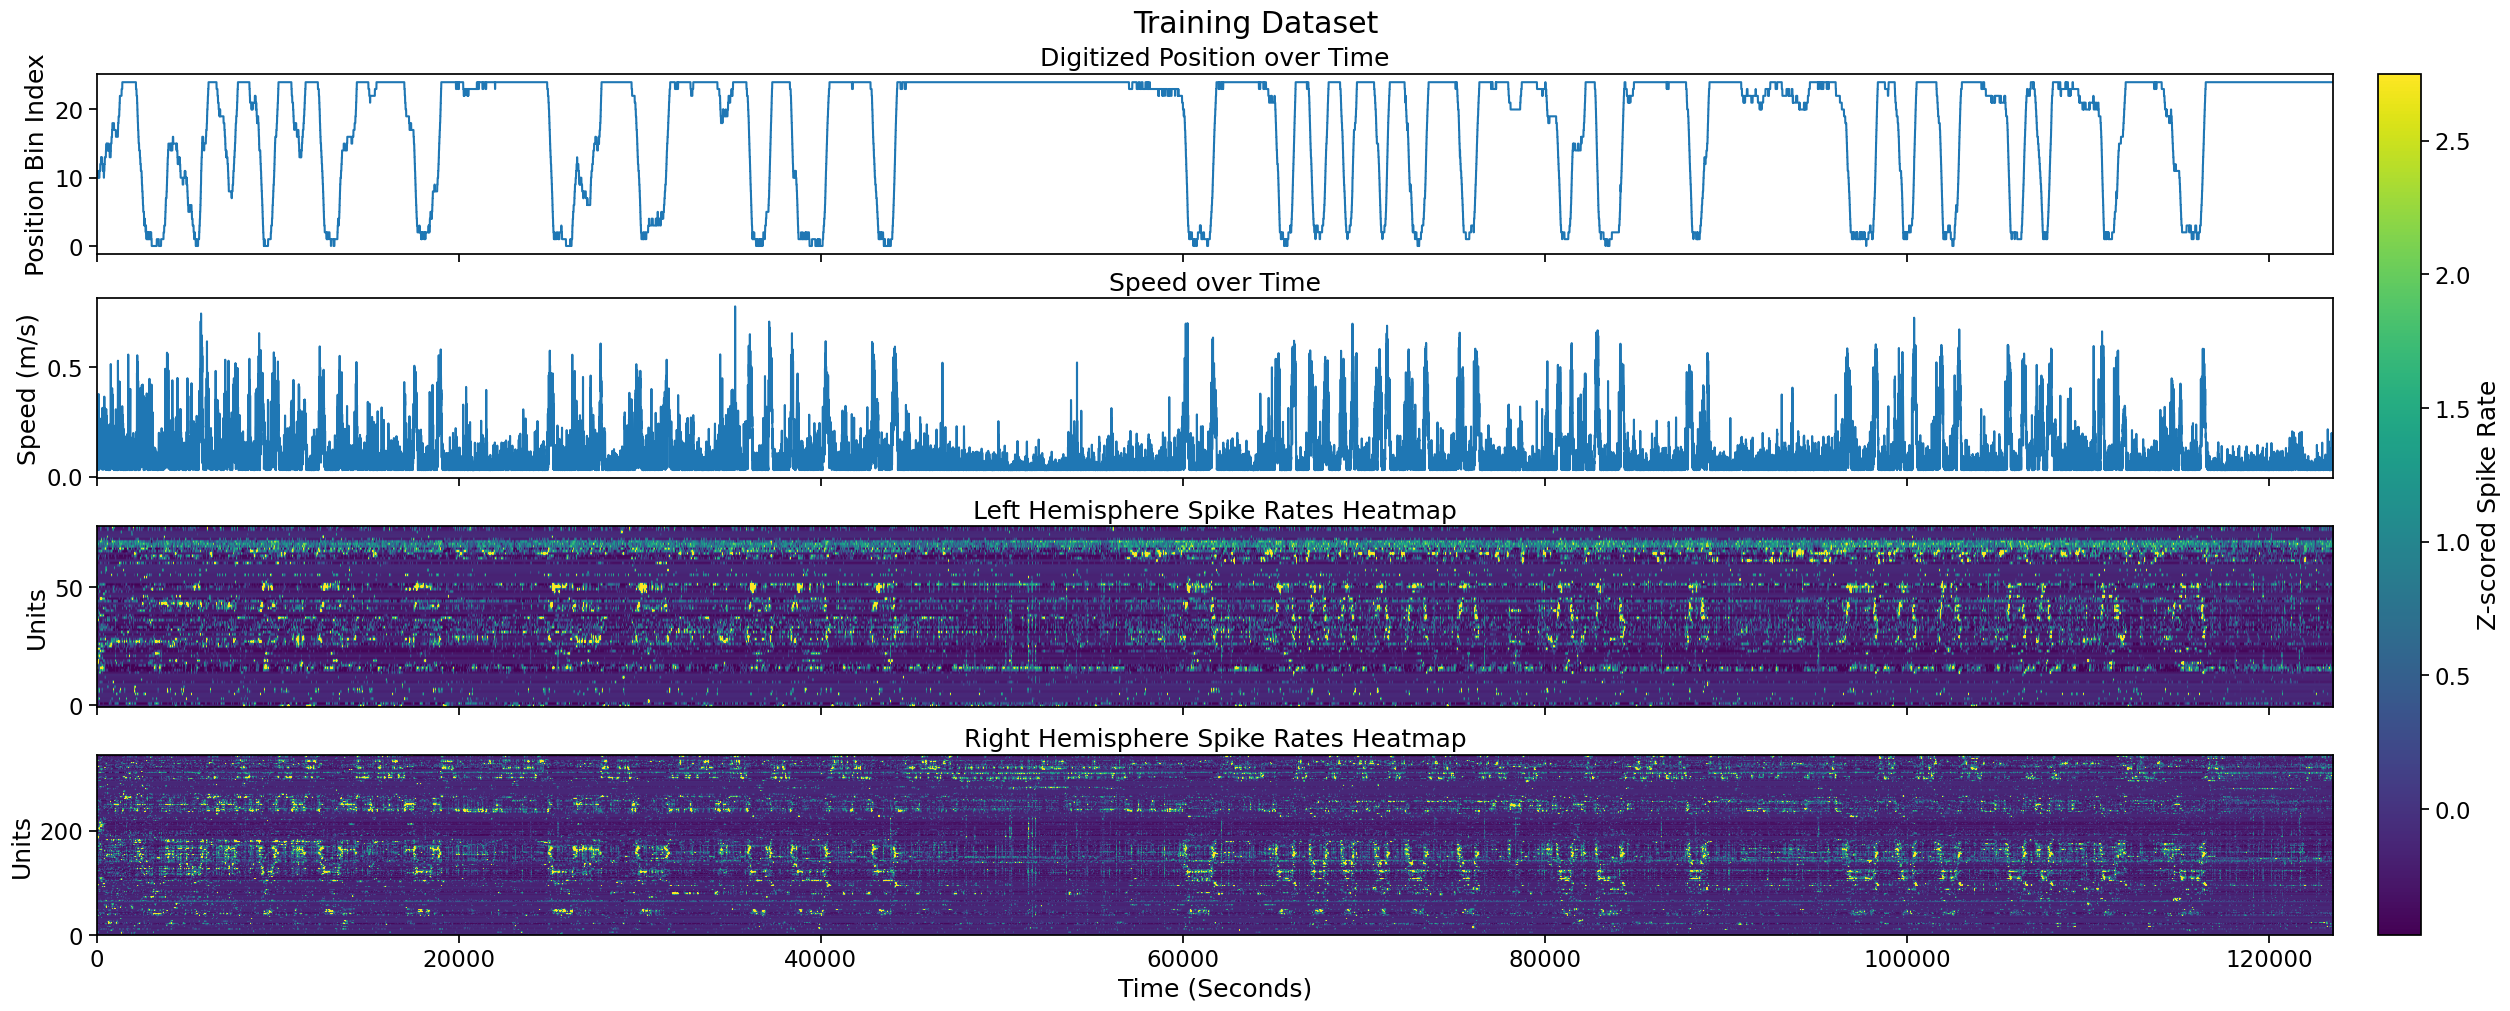

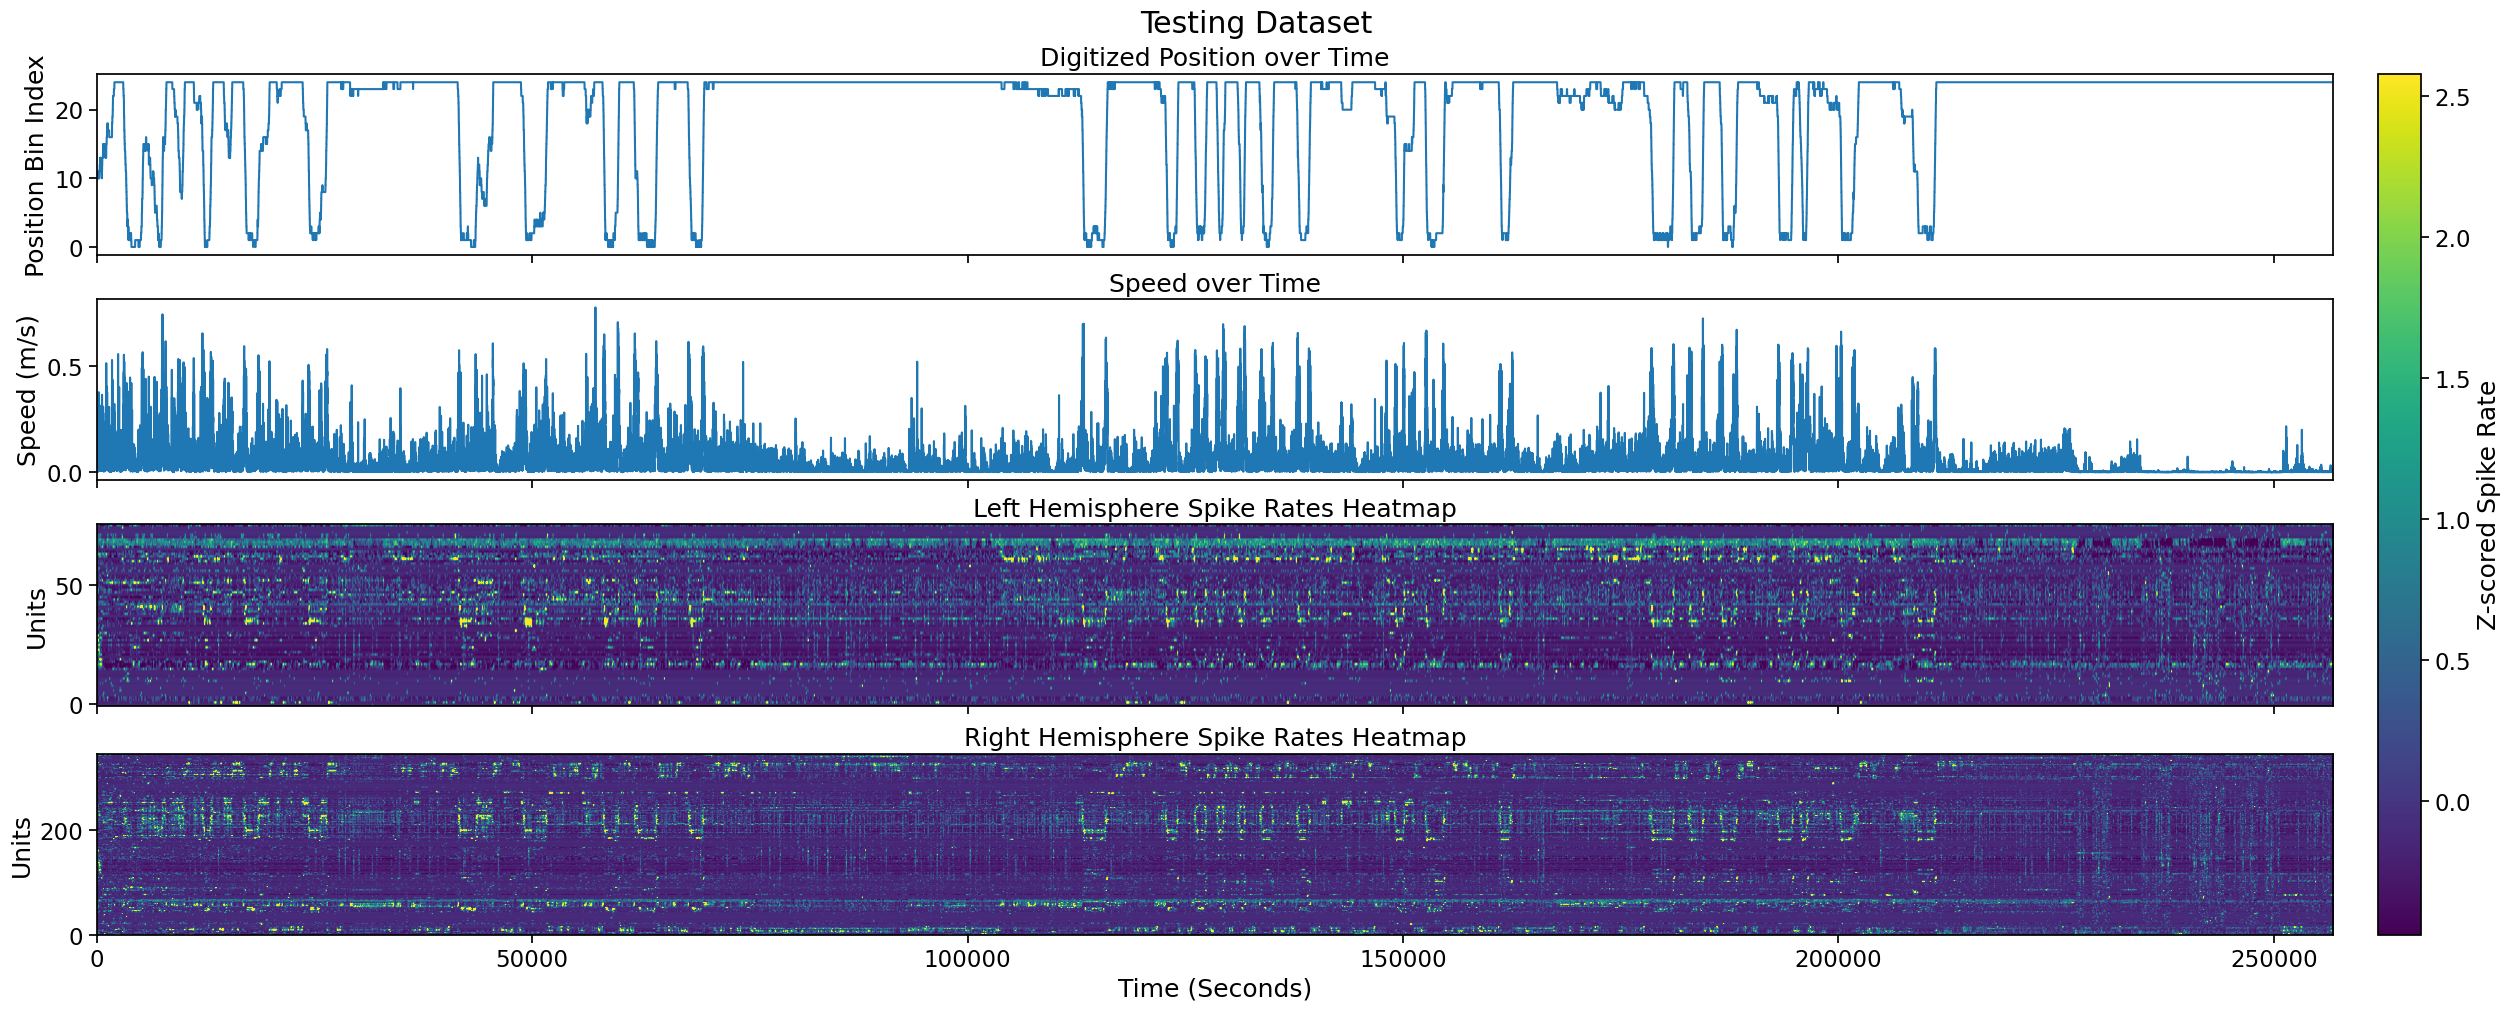

In [154]:
# plotting the datasets
for dataset in ['training', 'testing']:
    if dataset == 'training':
        spike_rates_concat_L = sorted_spike_rates_concat_train_L
        spike_rates_concat_R = sorted_spike_rates_concat_train_R
        pos_idx = pos_idx_train
        speed = speed_train
    elif dataset == 'testing':
        spike_rates_concat_L = sorted_spike_rates_concat_test_L
        spike_rates_concat_R = sorted_spike_rates_concat_test_R
        pos_idx = pos_idx_test
        speed = speed_test

    # computing vmin and vmax for color scaling
    vmin, vmax = np.percentile(np.concatenate([spike_rates_concat_L.ravel(), spike_rates_concat_R.ravel()]), [2.5, 97.5])

    dt = np.median(np.diff(time_bins))
    n_units_L = spike_rates_concat_L.shape[0]
    n_units_R = spike_rates_concat_R.shape[0]
    xmin = time_bins[0] - 0.5*dt
    xmax = time_bins[-1] + 0.5*dt

    fig, axs = plt.subplots(4, 1, figsize=(25, 10), sharex=True, constrained_layout=True)

    # Top: line
    axs[1].plot(speed)
    axs[1].set_ylabel('Speed (m/s)')
    axs[1].set_title('Speed over Time')
    axs[0].plot(pos_idx)
    axs[0].set_ylabel('Position Bin Index')
    axs[0].set_title('Digitized Position over Time')

    # Bottom: heatmap with true x via extent
    im = axs[2].imshow(
        spike_rates_concat_L, aspect='auto', origin='lower',
        #extent=[xmin, xmax, 0, n_units_L],
        vmin=vmin, vmax=vmax, cmap='viridis'
    )
    axs[2].set_title('Left Hemisphere Spike Rates Heatmap')

    # Bottom: heatmap with true x via extent
    im = axs[3].imshow(
        spike_rates_concat_R, aspect='auto', origin='lower',
        #extent=[xmin, xmax, 0, n_units_R],
        vmin=vmin, vmax=vmax, cmap='viridis'
    )
    axs[3].set_title('Right Hemisphere Spike Rates Heatmap')

    # Force identical x-lims on both axes


    # Colorbar attached to BOTH axes so layout stays symmetric
    cbar = fig.colorbar(im, ax=axs, location='right', fraction=0.02, pad=0.02)
    cbar.set_label('Z-scored Spike Rate')

    axs[3].set_xlabel('Time (Seconds)')
    axs[2].set_ylabel('Units')
    axs[3].set_ylabel('Units')
    plt.suptitle(f'{dataset.capitalize()} Dataset')

    #plt.savefig(os.path.join(FIG_DIR, f"spike_rates_and_position_{dataset}.png"), dpi=300)
    plt.show()

## Training and testing the Bayesian decoder

In [156]:
# define decoders
decoder_L = GaussianBayesDecoder(n_bins = n_spatial_bins, var_floor = 1e-4, uniform_prior=True)
decoder_R = GaussianBayesDecoder(n_bins = n_spatial_bins, var_floor = 1e-4, uniform_prior=True)

# fitting the decoders
decoder_L.fit(spike_rates_concat_train_L, pos_idx_train)
decoder_R.fit(spike_rates_concat_train_R, pos_idx_train)

# predicting on the test set
log_prob_test_L = decoder_L.predict_log_probabilities(spike_rates_concat_test_L)
log_prob_test_R = decoder_R.predict_log_probabilities(spike_rates_concat_test_R)

# getting MAP estimates
preds_L = np.argmax(log_prob_test_L, axis=0)
preds_R = np.argmax(log_prob_test_R, axis=0)

# converting log-probabilities to log-posteriors
posterior_L = np.exp(log_prob_test_L - logsumexp(log_prob_test_L, axis=0, keepdims=True))
posterior_R = np.exp(log_prob_test_R - logsumexp(log_prob_test_R, axis=0, keepdims=True))

In [ ]:
from ipywidgets import FloatSlider, VBox, HBox, Button, Output


fig_save_path = r'c:\Users\SB13FLPC020\OneDrive\Buzsaki Rotation Project\figures\decoding'
os.makedirs(fig_save_path, exist_ok=True)



T = preds_L.shape[0]

TIME_OFFSET = WINDOW_SIZE / 2.0
total_time = TIME_OFFSET + (T - 1) * STEP_SIZE
DEFAULT_DURATION_SEC = total_time / 50.0  # show 1/50 of session by default

GLOBAL_VMIN = np.nanpercentile(
    np.concatenate([posterior_L.ravel(), posterior_R.ravel()]),
    90
)
GLOBAL_VMAX = np.nanpercentile(
    np.concatenate([posterior_L.ravel(), posterior_R.ravel()]),
    100
)

from matplotlib.colors import Normalize
GLOBAL_NORM = Normalize(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)

def plot_segment_wake(start_sec=0.0, duration_sec=DEFAULT_DURATION_SEC):
    
    # clamp
    start_sec = max(0.0, min(start_sec, total_time))
    duration_sec = max(STEP_SIZE, duration_sec)

    # seconds → bin indices
    start_bin = int(round((start_sec - TIME_OFFSET) / STEP_SIZE))
    start_bin = max(0, min(start_bin, T - 1))

    end_sec = start_sec + duration_sec
    end_sec = min(end_sec, total_time)

    end_bin = int(round((end_sec - TIME_OFFSET) / STEP_SIZE)) + 1
    end_bin = max(start_bin + 1, min(end_bin, T))

    # x-range in seconds
    x_min = TIME_OFFSET + start_bin * STEP_SIZE
    x_max = TIME_OFFSET + (end_bin - 1) * STEP_SIZE
    y_min = 0
    y_max = posterior_L.shape[0]

    fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
    axL, axR = axs

    for side, to_plot, ax in zip(
        ['Left', 'Right'],
        [posterior_L, posterior_R],
        [axL, axR]
    ):

        im = ax.imshow(
            to_plot[:, start_bin:end_bin],
            aspect='auto',
            origin='lower',
            cmap='viridis',
            extent=[x_min, x_max, y_min, y_max],
            norm=GLOBAL_NORM,
        )

        # overlay true position
        t_slice = np.linspace(x_min, x_max, end_bin - start_bin)
        y_true_slice = pos_idx_test[start_bin:end_bin]

        ax.plot(
            t_slice,
            y_true_slice,
            color='k',
            alpha=0.4,
            linewidth=2,
            label='True position'
        )

        ax.set_ylabel('Position bins')
        ax.set_title(f'{side} Hemisphere Wake Decoding ')

    axR.set_xlabel('Time (s)')
    plt.tight_layout()

    return fig


# sliders
start_slider = FloatSlider(
    min=0.0, max=total_time, step=1.0, value=0.0, description='Start (s)'
)
duration_slider = FloatSlider(
    min=STEP_SIZE, max=total_time, step=1.0, value=DEFAULT_DURATION_SEC,
    description='Duration (s)'
)

# output area for plot
plot_out = Output()

# storage for last figure
current_fig = {'fig': None}

def update_plot(change=None):
    with plot_out:
        plot_out.clear_output(wait=True)
        fig = plot_segment_wake(start_slider.value, duration_slider.value)
        current_fig['fig'] = fig
        plt.show()

start_slider.observe(update_plot, names="value")
duration_slider.observe(update_plot, names="value")

# Save button
save_button = Button(description="Save Figure", button_style='success')

def save_fig_callback(b):
    fig = current_fig['fig']
    if fig is not None:
        fname = os.path.join(fig_save_path, f"wake_decoding_{start_slider.value:.2f}s_{duration_slider.value:.2f}s_pyramidalCells.png")
        fig.savefig(fname, dpi=200)
        print(f"Saved: {fname}")

save_button.on_click(save_fig_callback)

# initial plot
update_plot()

VBox([
    HBox([start_slider, duration_slider]),
    save_button,
    plot_out
])

## Testing the decoder durring sleep

In [158]:
sleep_time = (probe_times <= np.min(ttls)) | (probe_times >= np.max(ttls))
time_bins_sleep = probe_times[sleep_time]

spike_rates_sleep_L = []
spike_rates_sleep_R = []
# looping over probes to collect spike rates
for probe in PROBES:

    spike_rate_matrix, probe_times, units = spike_rate_matrices[probe]  # (n_units, n_timebins)
    hemisphere = hemisphere_dict[probe]

    print(f'Probe {probe} timebins length {len(probe_times)}: reference timebins length {len(tb_ref)}')
    if np.allclose(probe_times, tb_ref, rtol=0, atol=1e-9):
        print(f'Probe {probe} timebins successfully matched to reference timebins.\n')
    else:
        raise ValueError(f'Probe {probe} timebins do not match reference timebins. Lengths: {len(probe_times)} vs {len(tb_ref)}')

    spike_rate_matrix_sleep = spike_rate_matrix[:, sleep_time]
    probe_times = probe_times[sleep_time]




    ct_probe = np.asarray(cell_types[probe])                    # len == n_units
    rgn_arr = regions[probe]                                   # len == n_units

    # select units from the selected regions
    unit_sel = np.where(
        (np.isin(ct_probe, use_unit_types)) &
        (np.isin(rgn_arr, use_regions))
    )[0]

    if hemisphere == 'L':
        spike_rates_sleep_L.append(spike_rate_matrix_sleep[unit_sel, :])
    elif hemisphere == 'R':
        spike_rates_sleep_R.append(spike_rate_matrix_sleep[unit_sel, :])

# concatenating the selected spike rates across probes
spike_rates_concat_sleep_L = np.vstack(spike_rates_sleep_L) if len(spike_rates_sleep_L) > 0 else np.empty((0, 0))
spike_rates_concat_sleep_R = np.vstack(spike_rates_sleep_R) if len(spike_rates_sleep_R) > 0 else np.empty((0, 0))



Probe 0 timebins length 1052094: reference timebins length 1052094
Probe 0 timebins successfully matched to reference timebins.

Probe 1 timebins length 1052094: reference timebins length 1052094
Probe 1 timebins successfully matched to reference timebins.

Probe 2 timebins length 1052094: reference timebins length 1052094
Probe 2 timebins successfully matched to reference timebins.

Probe 3 timebins length 1052094: reference timebins length 1052094
Probe 3 timebins successfully matched to reference timebins.



In [159]:

# predicting on the test set
log_prob_test_L_sleep = decoder_L.predict_log_probabilities(spike_rates_concat_sleep_L)
log_prob_test_R_sleep = decoder_R.predict_log_probabilities(spike_rates_concat_sleep_R)

# getting MAP estimates
preds_L_sleep = np.argmax(log_prob_test_L_sleep, axis=0)
preds_R_sleep = np.argmax(log_prob_test_R_sleep, axis=0)

# converting log-probabilities to log-posteriors
posterior_L_sleep = np.exp(log_prob_test_L_sleep - logsumexp(log_prob_test_L_sleep, axis=0, keepdims=True))
posterior_R_sleep = np.exp(log_prob_test_R_sleep - logsumexp(log_prob_test_R_sleep, axis=0, keepdims=True))

In [160]:
# loading the sleep states
state_scoring_file = os.path.join(DATA_DIR, f'{BASE_NAME}_imec2.SleepState.states.mat')
mat = loadmat(state_scoring_file, squeeze_me=True, struct_as_record=False)

SleepState = mat['SleepState']       # MATLAB struct → Python object
states = SleepState.idx.states       # access idx.states hierarchy
states = (states + 1) // 2 
state_names = SleepState.idx.statenames  # access state names
idx = [0, 2, 4]
state_names = [SleepState.idx.statenames[i] for i in idx]

# resample the states (aligned to LFPs) to the decoder timebins
state_times = SleepState.idx.timestamps   # time vector for states in seconds

state_interp_func = interp1d(state_times, states, kind='nearest', bounds_error=False, fill_value='extrapolate')
decoder_time_states = state_interp_func(time_bins_sleep).astype(int)  # align to decoder time bins during sleep
print(f'Decoder time states shape: {decoder_time_states.shape}')

print(state_names)


Decoder time states shape: (795248,)
['WAKE', 'NREM', 'REM']


In [ ]:
from matplotlib.gridspec import GridSpec

# total time (using window centers)
TIME_OFFSET = WINDOW_SIZE / 2.0
total_time = TIME_OFFSET + (T - 1) * STEP_SIZE

# default duration in seconds
DEFAULT_DURATION_SEC = total_time / 100

# make sure states are ints
decoder_time_states = np.asarray(decoder_time_states).astype(int)

# assume codes are 1..N
n_states = len(state_names)
# simple discrete colormap (use any qualitative cmap you like)
base_colors = plt.cm.tab10.colors  # has at least 10 distinct colors
cmap_states = ListedColormap(base_colors[:n_states])

valid_codes = np.unique(decoder_time_states)
valid_codes = valid_codes[valid_codes > 0]     # ensure positive integer states
valid_labels = [state_names[c - 1] for c in valid_codes]



def plot_segment_sleep(start_sec=0.0, duration_sec=DEFAULT_DURATION_SEC):
    # clamp
    start_sec = max(0.0, min(start_sec, total_time))
    duration_sec = max(STEP_SIZE, duration_sec)

    # seconds → bin indices
    start_bin = int(round((start_sec - TIME_OFFSET) / STEP_SIZE))
    start_bin = max(0, min(start_bin, T - 1))

    end_sec = start_sec + duration_sec
    end_sec = min(end_sec, total_time)

    end_bin = int(round((end_sec - TIME_OFFSET) / STEP_SIZE)) + 1
    end_bin = max(start_bin + 1, min(end_bin, T))

    # x-range (seconds)
    x_min = TIME_OFFSET + start_bin * STEP_SIZE
    x_max = TIME_OFFSET + (end_bin - 1) * STEP_SIZE
    y_min = 0
    y_max = posterior_L_sleep.shape[0]

    fig = plt.figure(figsize=(20, 10))
    # 3 rows, 2 columns: left = data axes, right = colorbar
    gs = GridSpec(
        3, 2,
        figure=fig,
        width_ratios=[20, 1],          # wide data column, narrow cbar column
        height_ratios=[3, 3, 0.5]      # same ratios you had before
    )

    axL = fig.add_subplot(gs[0, 0])
    axR = fig.add_subplot(gs[1, 0], sharex=axL)
    axState = fig.add_subplot(gs[2, 0], sharex=axL)

    # ====== HEATMAPS =======
    for side, to_plot, ax in zip(
        ['Left', 'Right'],
        [posterior_L_sleep, posterior_R_sleep],
        [axL, axR]
    ):
        vmin = np.percentile(to_plot, 2.5)
        vmax = np.percentile(to_plot, 97.5)

        ax.imshow(
            to_plot[:, start_bin:end_bin],
            aspect='auto',
            origin='lower',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            extent=[x_min, x_max, y_min, y_max]
        )
        ax.set_ylabel('Position bins')
        ax.set_title(f'{side} Hemisphere Decoding')

    axL.tick_params(labelbottom=False)
    axR.set_xlabel("Time (s)")

    # ====== STATE BAR ======
    state_slice = decoder_time_states[start_bin:end_bin]
    state_img = state_slice[np.newaxis, :]

    im_state = axState.imshow(
        state_img,
        aspect='auto',
        origin='lower',
        cmap=cmap_states,
        extent=[x_min, x_max, 0, 1],
        vmin=0.5,
        vmax=n_states + 0.5
    )

    axState.set_yticks([])
    axState.set_ylabel('')
    axState.set_title("")

    # ====== COLORBAR IN ITS OWN COLUMN ======
    cax = fig.add_subplot(gs[2:, 1])  # spans all 3 rows on the right

    cbar = fig.colorbar(im_state, cax=cax, orientation='vertical')
    cbar.set_ticks(valid_codes)
    cbar.set_ticklabels(valid_labels)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()  # safe now
    plt.show()



# interactive widgets (seconds)
interact(
    plot_segment_sleep,
    start_sec=FloatSlider(
        min=0.0,
        max=total_time,
        step=1.0,
        value=0.0,
        description='Start (s)'
    ),
    duration_sec=FloatSlider(
        min=STEP_SIZE,
        max=total_time,
        step=1.0,
        value=DEFAULT_DURATION_SEC,
        description='Duration (s)'
    )
)



interactive(children=(FloatSlider(value=0.0, description='Start (s)', max=2568.4550000000004, step=1.0), Float…

<function __main__.plot_segment_sleep(start_sec=0.0, duration_sec=25.684550000000005)>

In [ ]:
import os
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
from ipywidgets import FloatSlider, Text, Button, VBox, HBox, Output


fig_save_path = r'c:\Users\SB13FLPC020\OneDrive\Buzsaki Rotation Project\figures\decoding_sleep'
os.makedirs(fig_save_path, exist_ok=True)

# total time (using window centers)
TIME_OFFSET = WINDOW_SIZE / 2.0
T = posterior_L_sleep.shape[1]   # or preds_L.shape[0], must match
total_time = TIME_OFFSET + (T - 1) * STEP_SIZE

# default duration in seconds
DEFAULT_DURATION_SEC = total_time / 100

# make sure states are ints
decoder_time_states = np.asarray(decoder_time_states).astype(int)

# assume codes are 1..N
n_states = len(state_names)
base_colors = plt.cm.tab10.colors  # qualitative cmap
cmap_states = ListedColormap(base_colors[:n_states])

valid_codes = np.unique(decoder_time_states)
valid_codes = valid_codes[valid_codes > 0]     # ensure positive integer states
valid_labels = [state_names[c - 1] for c in valid_codes]


def plot_segment_sleep(start_sec=0.0, duration_sec=DEFAULT_DURATION_SEC):
    # clamp
    start_sec = max(0.0, min(start_sec, total_time))
    duration_sec = max(STEP_SIZE, duration_sec)

    # seconds → bin indices
    start_bin = int(round((start_sec - TIME_OFFSET) / STEP_SIZE))
    start_bin = max(0, min(start_bin, T - 1))

    end_sec = start_sec + duration_sec
    end_sec = min(end_sec, total_time)

    end_bin = int(round((end_sec - TIME_OFFSET) / STEP_SIZE)) + 1
    end_bin = max(start_bin + 1, min(end_bin, T))

    # x-range (seconds)
    x_min = TIME_OFFSET + start_bin * STEP_SIZE
    x_max = TIME_OFFSET + (end_bin - 1) * STEP_SIZE
    y_min = 0
    y_max = posterior_L_sleep.shape[0]

    fig = plt.figure(figsize=(20, 10))
    # 3 rows, 2 columns: left = data axes, right = colorbar
    gs = GridSpec(
        3, 2,
        figure=fig,
        width_ratios=[20, 1],          # wide data column, narrow cbar column
        height_ratios=[3, 3, 0.5]      # same ratios you had before
    )

    axL = fig.add_subplot(gs[0, 0])
    axR = fig.add_subplot(gs[1, 0], sharex=axL)
    axState = fig.add_subplot(gs[2, 0], sharex=axL)

    # ====== HEATMAPS =======
    for side, to_plot, ax in zip(
        ['Left', 'Right'],
        [posterior_L_sleep, posterior_R_sleep],
        [axL, axR]
    ):
        vmin = np.percentile(to_plot, 2.5)
        vmax = np.percentile(to_plot, 97.5)

        ax.imshow(
            to_plot[:, start_bin:end_bin],
            aspect='auto',
            origin='lower',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            extent=[x_min, x_max, y_min, y_max]
        )
        ax.set_ylabel('Position bins')
        ax.set_title(f'{side} Hemisphere Decoding')

    axL.tick_params(labelbottom=False)
    axR.set_xlabel("Time (s)")

    # ====== STATE BAR ======
    state_slice = decoder_time_states[start_bin:end_bin]
    state_img = state_slice[np.newaxis, :]

    im_state = axState.imshow(
        state_img,
        aspect='auto',
        origin='lower',
        cmap=cmap_states,
        extent=[x_min, x_max, 0, 1],
        vmin=0.5,
        vmax=n_states + 0.5
    )

    axState.set_yticks([])
    axState.set_ylabel('')
    axState.set_title("")

    # ====== COLORBAR IN ITS OWN COLUMN ======
    cax = fig.add_subplot(gs[2:, 1])  # spans all 3 rows on the right

    cbar = fig.colorbar(im_state, cax=cax, orientation='vertical')
    cbar.set_ticks(valid_codes)
    cbar.set_ticklabels(valid_labels)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    return fig


# ---------- widgets: sliders + save dir + save button ----------

start_slider_sleep = FloatSlider(
    min=0.0,
    max=total_time,
    step=1.0,
    value=0.0,
    description='Start (s)'
)

duration_slider_sleep = FloatSlider(
    min=STEP_SIZE,
    max=total_time,
    step=1.0,
    value=DEFAULT_DURATION_SEC,
    description='Duration (s)'
)

save_dir_sleep = Text(
    value='.',
    description='Save dir:',
    layout={'width': '400px'}
)

save_button_sleep = Button(
    description='Save figure',
    button_style='success'
)

plot_out_sleep = Output()
_current_fig_sleep = {'fig': None}


def update_plot_sleep(change=None):
    with plot_out_sleep:
        plot_out_sleep.clear_output(wait=True)
        fig = plot_segment_sleep(start_slider_sleep.value, duration_slider_sleep.value)
        _current_fig_sleep['fig'] = fig
        plt.show(fig)


def on_save_clicked_sleep(b):
    fig = _current_fig_sleep.get('fig')
    if fig is None:
        return

    save_dir = save_dir_sleep.value.strip()
    if save_dir == '':
        save_dir = '.'

    os.makedirs(save_dir, exist_ok=True)

    start = start_slider_sleep.value
    dur = duration_slider_sleep.value
    fname = f"sleep_decoding_{start:.2f}s_{dur:.2f}s.png"
    fpath = os.path.join(fig_save_path, fname)

    fig.savefig(fpath, dpi=300, bbox_inches='tight')
    with plot_out_sleep:
        print(f"Saved: {fpath}")


start_slider_sleep.observe(update_plot_sleep, names='value')
duration_slider_sleep.observe(update_plot_sleep, names='value')
save_button_sleep.on_click(on_save_clicked_sleep)

# initial draw
update_plot_sleep()

VBox([
    HBox([start_slider_sleep, duration_slider_sleep]),
    HBox([save_dir_sleep, save_button_sleep]),
    plot_out_sleep
])


## Running the Gaussian Process Latent Variable Model


### Waking period

In [169]:
Niters = 1000
random_latents = True
patience = 100

# define decoders
latent_decoder_L = GaussianBayesDecoder(n_bins = n_spatial_bins, var_floor = 1e-4, uniform_prior=False)
latent_decoder_R = GaussianBayesDecoder(n_bins = n_spatial_bins, var_floor = 1e-4, uniform_prior=False)


if random_latents:
    latents = np.random.randint(0, n_spatial_bins, size=pos_idx_train.shape[0])
else:
    latents = pos_idx_train

diffs_L = []
diffs_R = []
latents_L = latents
latents_R = latents

# training loop
for iter in range(Niters):
    print(f'Iteration {iter + 1} / {Niters}')

    # fitting the decoders
    if iter == 0:
        print('Fitting with initial latents (position indices or random latents).')
        srl = spike_rates_concat_train_L
        srr = spike_rates_concat_train_R
    else:
        print('Fitting with updated latents from previous iteration.')
        srl = spike_rates_concat_test_L
        srr = spike_rates_concat_test_R

    latent_decoder_L.fit(srl, latents_L)
    latent_decoder_R.fit(srr, latents_R)

    # predicting on the test set
    latent_log_prob_test_L = latent_decoder_L.predict_log_probabilities(spike_rates_concat_test_L)
    latent_log_prob_test_R = latent_decoder_R.predict_log_probabilities(spike_rates_concat_test_R)

    # getting MAP estimates
    new_latents_L = np.argmax(latent_log_prob_test_L, axis=0)
    new_latents_R = np.argmax(latent_log_prob_test_R, axis=0)

    # converting log-probabilities to log-posteriors
    latent_posterior_L = np.exp(latent_log_prob_test_L - logsumexp(latent_log_prob_test_L, axis=0, keepdims=True))
    latent_posterior_R = np.exp(latent_log_prob_test_R - logsumexp(latent_log_prob_test_R, axis=0, keepdims=True))

    if iter != 0:
        diffs_L.append(np.sum(new_latents_L != latents_L))
        diffs_R.append(np.sum(new_latents_R != latents_R))
        print(f'difference L: {diffs_L[-1]:.4f}, difference R: {diffs_R[-1]:.4f}\n')

        # early stopping check
        if diffs_L[-1] == 0 and diffs_R[-1] == 0:
            print(f'Converged at iteration {iter + 1} with zero differences.\n')
            break
        if iter >= patience:
            diff_history_L = diffs_L[-patience:]
            diff_history_R = diffs_R[-patience:]

            if (diffs_L[-1] >= max(diff_history_L) and
                diffs_R[-1] >= max(diff_history_R)):
                print(f'Early stopping at iteration {iter + 1} due to no improvement in last {patience} iterations.\n')
                break

    latents_L = new_latents_L
    latents_R = new_latents_R



Iteration 1 / 1000
Fitting with initial latents (position indices or random latents).
Iteration 2 / 1000
Fitting with updated latents from previous iteration.
difference L: 76896.0000, difference R: 88116.0000

Iteration 3 / 1000
Fitting with updated latents from previous iteration.
difference L: 40251.0000, difference R: 55696.0000

Iteration 4 / 1000
Fitting with updated latents from previous iteration.
difference L: 30510.0000, difference R: 39867.0000

Iteration 5 / 1000
Fitting with updated latents from previous iteration.
difference L: 31691.0000, difference R: 30034.0000

Iteration 6 / 1000
Fitting with updated latents from previous iteration.
difference L: 30991.0000, difference R: 23910.0000

Iteration 7 / 1000
Fitting with updated latents from previous iteration.
difference L: 30030.0000, difference R: 19440.0000

Iteration 8 / 1000
Fitting with updated latents from previous iteration.
difference L: 26383.0000, difference R: 15873.0000

Iteration 9 / 1000
Fitting with updated

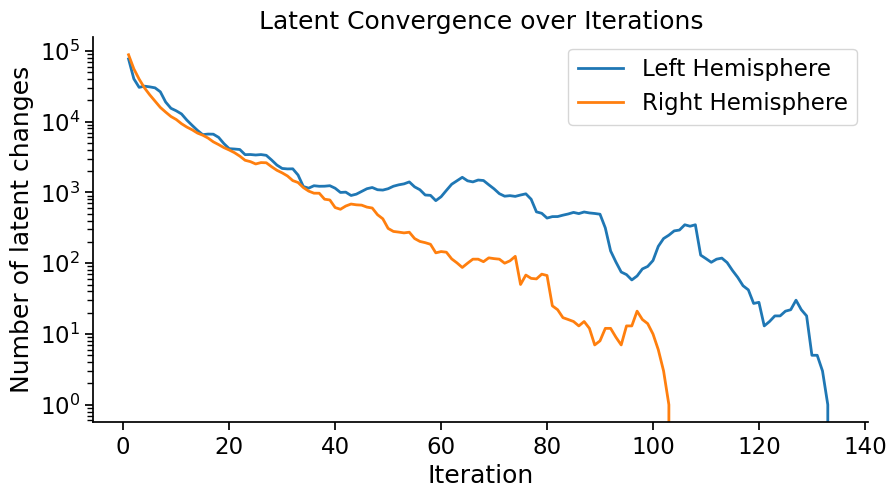

In [170]:
# plot the diffs
plt.figure(figsize=(10,5))
plt.plot(range(1, len(diffs_L) + 1), diffs_L, label='Left Hemisphere', linewidth=2)
plt.plot(range(1, len(diffs_R) + 1), diffs_R, label='Right Hemisphere', linewidth=2)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Number of latent changes')
plt.title('Latent Convergence over Iterations')
plt.legend()
sns.despine()
plt.show()


In [ ]:
from ipywidgets import FloatSlider, VBox, HBox, Button, Output


fig_save_path = r'c:\Users\SB13FLPC020\OneDrive\Buzsaki Rotation Project\figures\latent_variable_model_10ms'
os.makedirs(fig_save_path, exist_ok=True)



T = preds_L.shape[0]

TIME_OFFSET = WINDOW_SIZE / 2.0
total_time = TIME_OFFSET + (T - 1) * STEP_SIZE
DEFAULT_DURATION_SEC = total_time / 50.0  # show 1/50 of session by default

GLOBAL_VMIN = np.nanpercentile(
    np.concatenate([posterior_L.ravel(), posterior_R.ravel()]),
    90
)
GLOBAL_VMAX = np.nanpercentile(
    np.concatenate([posterior_L.ravel(), posterior_R.ravel()]),
    100
)

from matplotlib.colors import Normalize
GLOBAL_NORM = Normalize(vmin=GLOBAL_VMIN, vmax=GLOBAL_VMAX)

def plot_latent_segment_wake(start_sec=0.0, duration_sec=DEFAULT_DURATION_SEC):
    
    # clamp
    start_sec = max(0.0, min(start_sec, total_time))
    duration_sec = max(STEP_SIZE, duration_sec)

    # seconds → bin indices
    start_bin = int(round((start_sec - TIME_OFFSET) / STEP_SIZE))
    start_bin = max(0, min(start_bin, T - 1))

    end_sec = start_sec + duration_sec
    end_sec = min(end_sec, total_time)

    end_bin = int(round((end_sec - TIME_OFFSET) / STEP_SIZE)) + 1
    end_bin = max(start_bin + 1, min(end_bin, T))

    # x-range in seconds
    x_min = TIME_OFFSET + start_bin * STEP_SIZE
    x_max = TIME_OFFSET + (end_bin - 1) * STEP_SIZE
    y_min = 0
    y_max = posterior_L.shape[0]

    fig, axs = plt.subplots(2, 1, figsize=(20, 10), sharex=True)
    axL, axR = axs

    for side, to_plot, ax in zip(
        ['Left', 'Right'],
        [latent_posterior_L, latent_posterior_R],
        [axL, axR]
    ):

        im = ax.imshow(
            to_plot[:, start_bin:end_bin],
            aspect='auto',
            origin='lower',
            cmap='viridis',
            extent=[x_min, x_max, y_min, y_max],
            norm=GLOBAL_NORM,
        )

        # overlay true position
        t_slice = np.linspace(x_min, x_max, end_bin - start_bin)
        y_true_slice = pos_idx_test[start_bin:end_bin]

        ax.plot(
            t_slice,
            y_true_slice,
            color='k',
            alpha=0.4,
            linewidth=2,
            label='True position'
        )

        ax.set_ylabel('latent bins')
        ax.set_title(f'{side} Hemisphere Wake Decoding ')

    axR.set_xlabel('Time (s)')
    plt.tight_layout()

    return fig


# sliders
start_slider = FloatSlider(
    min=0.0, max=total_time, step=1.0, value=0.0, description='Start (s)'
)
duration_slider = FloatSlider(
    min=STEP_SIZE, max=total_time, step=1.0, value=DEFAULT_DURATION_SEC,
    description='Duration (s)'
)

# output area for plot
plot_out = Output()

# storage for last figure
current_fig = {'fig': None}

def update_plot(change=None):
    with plot_out:
        plot_out.clear_output(wait=True)
        fig = plot_latent_segment_wake(start_slider.value, duration_slider.value)
        current_fig['fig'] = fig
        plt.show()

start_slider.observe(update_plot, names="value")
duration_slider.observe(update_plot, names="value")

# Save button
save_button = Button(description="Save Figure", button_style='success')

def save_fig_callback(b):
    fig = current_fig['fig']
    if fig is not None:
        fname = os.path.join(fig_save_path, f"wake__{start_slider.value:.2f}s_{duration_slider.value:.2f}s_pyramidalCells.png")
        fig.savefig(fname, dpi=200)
        print(f"Saved: {fname}")

save_button.on_click(save_fig_callback)

# initial plot
update_plot()

VBox([
    HBox([start_slider, duration_slider]),
    save_button,
    plot_out
])

### Sleep

In [173]:
Niters = 1000
random_latents = True
patience = 200

# define decoders
latent_sleep_decoder_L = GaussianBayesDecoder(n_bins = n_spatial_bins, var_floor = 1e-4, uniform_prior=False)
latent_sleep_decoder_R = GaussianBayesDecoder(n_bins = n_spatial_bins, var_floor = 1e-4, uniform_prior=False)


if random_latents:
    latents = np.random.randint(0, n_spatial_bins, size=pos_idx_train.shape[0])
else:
    # fitting the decoders
    latent_sleep_decoder_L.fit(spike_rates_concat_train_L, pos_idx_train)
    latent_sleep_decoder_R.fit(spike_rates_concat_train_R, pos_idx_train)

    sleep_latenets_L = np.argmax(latent_sleep_decoder_L.predict_log_probabilities(spike_rates_concat_test_L), axis=0)
    sleep_latents_R = np.argmax(latent_sleep_decoder_R.predict_log_probabilities(spike_rates_concat_test_R), axis=0)

diffs_L = []
diffs_R = []
sleep_latents_L = latents
sleep_latents_R = latents

# training loop
for iter in range(Niters):
    print(f'Iteration {iter + 1} / {Niters}')

    # fitting the decoders
    if iter == 0:
        print('Fitting with initial latents (position indices or random latents).')
        srl = spike_rates_concat_train_L
        srr = spike_rates_concat_train_R
    else:
        print('Fitting with updated latents from previous iteration.')
        srl = spike_rates_concat_test_L
        srr = spike_rates_concat_test_R

    latent_decoder_L.fit(srl, sleep_latents_L)
    latent_decoder_R.fit(srr, sleep_latents_R)

    # predicting on the test set
    latent_log_prob_test_L = latent_decoder_L.predict_log_probabilities(spike_rates_concat_test_L)
    latent_log_prob_test_R = latent_decoder_R.predict_log_probabilities(spike_rates_concat_test_R)

    # getting MAP estimates
    new_latents_L = np.argmax(latent_log_prob_test_L, axis=0)
    new_latents_R = np.argmax(latent_log_prob_test_R, axis=0)

    # converting log-probabilities to log-posteriors
    latent_sleep_posterior_L = np.exp(latent_log_prob_test_L - logsumexp(latent_log_prob_test_L, axis=0, keepdims=True))
    latent_sleep_posterior_R = np.exp(latent_log_prob_test_R - logsumexp(latent_log_prob_test_R, axis=0, keepdims=True))

    if iter != 0:
        diffs_L.append(np.sum(new_latents_L != latents_L))
        diffs_R.append(np.sum(new_latents_R != latents_R))
        print(f'difference L: {diffs_L[-1]:.4f}, difference R: {diffs_R[-1]:.4f}\n')

            # early stopping check
        if diffs_L[-1] == 0 and diffs_R[-1] == 0:
            print(f'Converged at iteration {iter + 1} with zero differences.\n')
            break
        
        if iter >= patience:
            diff_history_L = diffs_L[-patience:]
            diff_history_R = diffs_R[-patience:]

            if (diffs_L[-1] >= max(diff_history_L) and
                diffs_R[-1] >= max(diff_history_R)):
                print(f'Early stopping at iteration {iter + 1} due to no improvement in last {patience} iterations.\n')
                break

    sleep_latents_L = new_latents_L
    sleep_latents_R = new_latents_R



Iteration 1 / 1000
Fitting with initial latents (position indices or random latents).
Iteration 2 / 1000
Fitting with updated latents from previous iteration.
difference L: 252103.0000, difference R: 247263.0000

Iteration 3 / 1000
Fitting with updated latents from previous iteration.
difference L: 250758.0000, difference R: 246810.0000

Iteration 4 / 1000
Fitting with updated latents from previous iteration.
difference L: 250211.0000, difference R: 246829.0000

Iteration 5 / 1000
Fitting with updated latents from previous iteration.
difference L: 250158.0000, difference R: 247660.0000

Iteration 6 / 1000
Fitting with updated latents from previous iteration.
difference L: 250141.0000, difference R: 247922.0000

Iteration 7 / 1000
Fitting with updated latents from previous iteration.
difference L: 250229.0000, difference R: 247856.0000

Iteration 8 / 1000
Fitting with updated latents from previous iteration.
difference L: 250371.0000, difference R: 247556.0000

Iteration 9 / 1000
Fittin

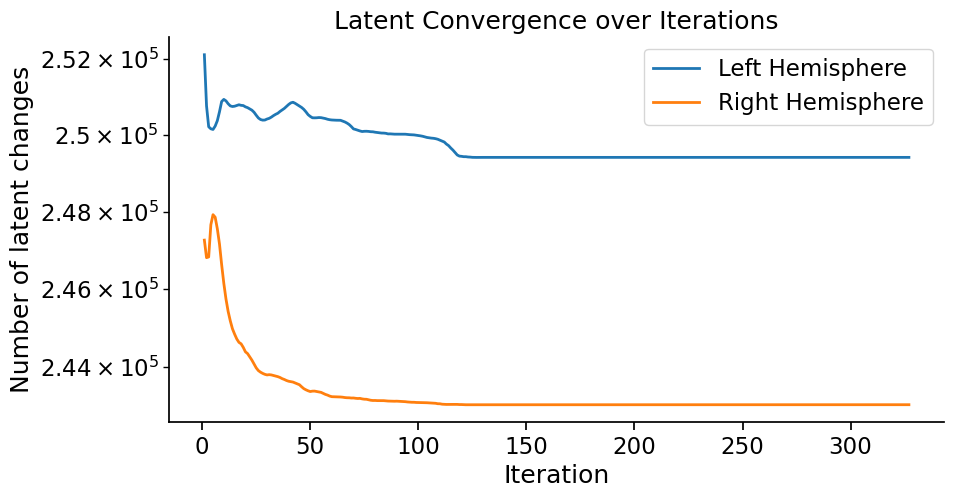

In [174]:
# plot the diffs
plt.figure(figsize=(10,5))
plt.plot(range(1, len(diffs_L) + 1), diffs_L, label='Left Hemisphere', linewidth=2)
plt.plot(range(1, len(diffs_R) + 1), diffs_R, label='Right Hemisphere', linewidth=2)
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('Number of latent changes')
plt.title('Latent Convergence over Iterations')
plt.legend()
sns.despine()
plt.show()


In [ ]:
import os
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
from ipywidgets import FloatSlider, Text, Button, VBox, HBox, Output


fig_save_path = r'c:\Users\SB13FLPC020\OneDrive\Buzsaki Rotation Project\figures\latent_variable_model_sleep'
os.makedirs(fig_save_path, exist_ok=True)

# total time (using window centers)
TIME_OFFSET = WINDOW_SIZE / 2.0
T = latent_sleep_posterior_L.shape[1]   # or preds_L.shape[0], must match
total_time = TIME_OFFSET + (T - 1) * STEP_SIZE

# default duration in seconds
DEFAULT_DURATION_SEC = total_time / 100

# make sure states are ints
decoder_time_states = np.asarray(decoder_time_states).astype(int)

# assume codes are 1..N
n_states = len(state_names)
base_colors = plt.cm.tab10.colors  # qualitative cmap
cmap_states = ListedColormap(base_colors[:n_states])

valid_codes = np.unique(decoder_time_states)
valid_codes = valid_codes[valid_codes > 0]     # ensure positive integer states
valid_labels = [state_names[c - 1] for c in valid_codes]


def plot_segment_sleep(start_sec=0.0, duration_sec=DEFAULT_DURATION_SEC):
    # clamp
    start_sec = max(0.0, min(start_sec, total_time))
    duration_sec = max(STEP_SIZE, duration_sec)

    # seconds → bin indices
    start_bin = int(round((start_sec - TIME_OFFSET) / STEP_SIZE))
    start_bin = max(0, min(start_bin, T - 1))

    end_sec = start_sec + duration_sec
    end_sec = min(end_sec, total_time)

    end_bin = int(round((end_sec - TIME_OFFSET) / STEP_SIZE)) + 1
    end_bin = max(start_bin + 1, min(end_bin, T))

    # x-range (seconds)
    x_min = TIME_OFFSET + start_bin * STEP_SIZE
    x_max = TIME_OFFSET + (end_bin - 1) * STEP_SIZE
    y_min = 0
    y_max = latent_sleep_posterior_L.shape[0]

    fig = plt.figure(figsize=(20, 10))
    # 3 rows, 2 columns: left = data axes, right = colorbar
    gs = GridSpec(
        3, 2,
        figure=fig,
        width_ratios=[20, 1],          # wide data column, narrow cbar column
        height_ratios=[3, 3, 0.5]      # same ratios you had before
    )

    axL = fig.add_subplot(gs[0, 0])
    axR = fig.add_subplot(gs[1, 0], sharex=axL)
    axState = fig.add_subplot(gs[2, 0], sharex=axL)

    # ====== HEATMAPS =======
    for side, to_plot, ax in zip(
        ['Left', 'Right'],
        [latent_sleep_posterior_L, latent_sleep_posterior_R],
        [axL, axR]
    ):
        vmin = np.percentile(to_plot, 2.5)
        vmax = np.percentile(to_plot, 97.5)

        ax.imshow(
            to_plot[:, start_bin:end_bin],
            aspect='auto',
            origin='lower',
            cmap='viridis',
            vmin=vmin,
            vmax=vmax,
            extent=[x_min, x_max, y_min, y_max]
        )
        ax.set_ylabel('Position bins')
        ax.set_title(f'{side} Hemisphere Decoding')

    axL.tick_params(labelbottom=False)
    axR.set_xlabel("Time (s)")

    # ====== STATE BAR ======
    state_slice = decoder_time_states[start_bin:end_bin]
    state_img = state_slice[np.newaxis, :]

    im_state = axState.imshow(
        state_img,
        aspect='auto',
        origin='lower',
        cmap=cmap_states,
        extent=[x_min, x_max, 0, 1],
        vmin=0.5,
        vmax=n_states + 0.5
    )

    axState.set_yticks([])
    axState.set_ylabel('')
    axState.set_title("")

    # ====== COLORBAR IN ITS OWN COLUMN ======
    cax = fig.add_subplot(gs[2:, 1])  # spans all 3 rows on the right

    cbar = fig.colorbar(im_state, cax=cax, orientation='vertical')
    cbar.set_ticks(valid_codes)
    cbar.set_ticklabels(valid_labels)
    cbar.ax.tick_params(labelsize=8)

    plt.tight_layout()
    return fig


# ---------- widgets: sliders + save dir + save button ----------

start_slider_sleep = FloatSlider(
    min=0.0,
    max=total_time,
    step=1.0,
    value=0.0,
    description='Start (s)'
)

duration_slider_sleep = FloatSlider(
    min=STEP_SIZE,
    max=total_time,
    step=1.0,
    value=DEFAULT_DURATION_SEC,
    description='Duration (s)'
)

save_dir_sleep = Text(
    value='.',
    description='Save dir:',
    layout={'width': '400px'}
)

save_button_sleep = Button(
    description='Save figure',
    button_style='success'
)

plot_out_sleep = Output()
_current_fig_sleep = {'fig': None}


def update_plot_sleep(change=None):
    with plot_out_sleep:
        plot_out_sleep.clear_output(wait=True)
        fig = plot_segment_sleep(start_slider_sleep.value, duration_slider_sleep.value)
        _current_fig_sleep['fig'] = fig
        plt.show(fig)


def on_save_clicked_sleep(b):
    fig = _current_fig_sleep.get('fig')
    if fig is None:
        return

    save_dir = save_dir_sleep.value.strip()
    if save_dir == '':
        save_dir = '.'

    os.makedirs(save_dir, exist_ok=True)

    start = start_slider_sleep.value
    dur = duration_slider_sleep.value
    fname = f"sleep_decoding_{start:.2f}s_{dur:.2f}s.png"
    fpath = os.path.join(fig_save_path, fname)

    fig.savefig(fpath, dpi=300, bbox_inches='tight')
    with plot_out_sleep:
        print(f"Saved: {fpath}")


start_slider_sleep.observe(update_plot_sleep, names='value')
duration_slider_sleep.observe(update_plot_sleep, names='value')
save_button_sleep.on_click(on_save_clicked_sleep)

# initial draw
update_plot_sleep()

VBox([
    HBox([start_slider_sleep, duration_slider_sleep]),
    HBox([save_dir_sleep, save_button_sleep]),
    plot_out_sleep
])
